In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def load_power(direc = "", filename=None):
    """Load a power spectrum file with columns k, power, modes.
    Removes rows where k is nan or where k/power are zero."""
    k, power, modes = np.loadtxt(direc+"output/"+filename, unpack=True)
    mask = np.isfinite(k) & np.isfinite(power) & (k > 0) & (power > 0)
    return k[mask], power[mask], modes[mask]


In [15]:
dir = ["keir_recon", "keir_reion_same_t"]

scale_factors = [0.1681, 0.1792, 0.1908]
snap_num = [7, 8, 10]
redshifts = [1 / a - 1 for a in scale_factors]

# power_data[model][a] = {"dm": (k, P), "bar": (k, P)}
power_data = {model: {} for model in dir}
for model in dir:
    for a in scale_factors:
        k_dm, power_dm, modes_dm = load_power(direc=f"{model}/", filename=f"power-DM-{a}.txt")
        k_bar, power_bar, modes_bar = load_power(direc=f"{model}/", filename=f"power-bar-{a}.txt")
        power_data[model][a] = {"dm": (k_dm, power_dm), "bar": (k_bar, power_bar)}

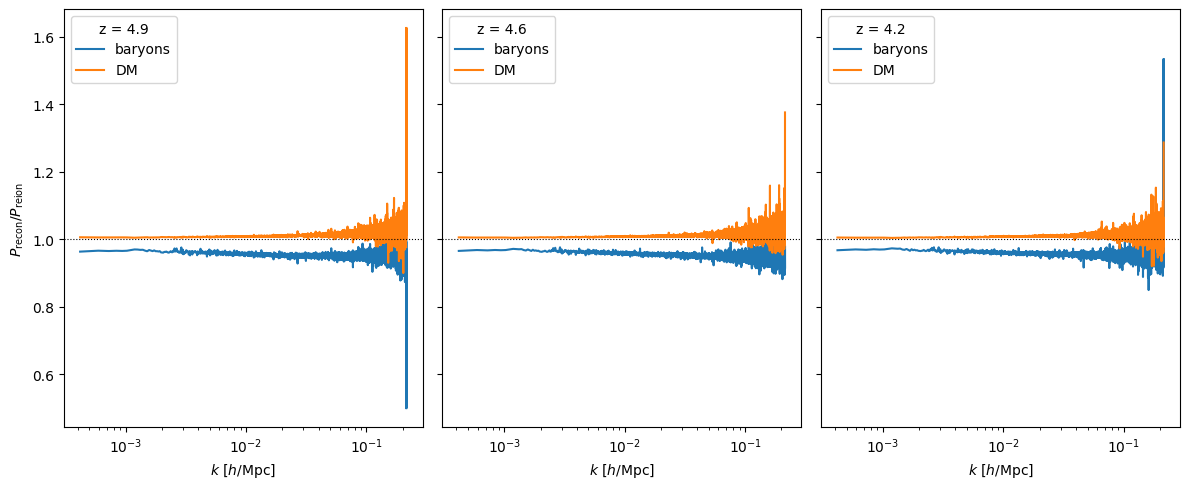

In [ ]:
# Ratio recon / reion for each species, per redshift

fig, axes = plt.subplots(1, len(scale_factors), figsize=(4* len(scale_factors), 5), sharex=True, sharey=True)

for ax, a, z in zip(axes, scale_factors, redshifts):
    for species in ["bar", "dm"]:
        k_recon, p_recon = power_data["keir_recon"][a][species]
        k_reion, p_reion = power_data["keir_reion_same_t"][a][species]
        # evaluate reion on the recon k grid before dividing
        p_reion_i = np.interp(k_recon, k_reion, p_reion)
        ratio = p_recon / p_reion_i
        ax.semilogx(k_recon, ratio, label={"bar": "baryons", "dm": "DM"}[species])
    ax.axhline(1.0, color="k", ls=":", lw=0.8)
    ax.legend(loc='upper left',title=f"z = {z:.1f}")
    ax.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$")

axes[0].set_ylabel(r"$P_{\rm recon}/P_{\rm reion}$")
for ax in axes[1:]:
    ax.tick_params(axis="y", which="both", labelleft=False)
plt.tight_layout()

In [33]:
from lyaemu import lyman_data

# Save data
flux_power_data = {model: {} for model in dir}
obser_data = lyman_data.BoeraData()
kf = obser_data.get_kf()    # km / s

for snap_i, a, z in zip(snap_num, scale_factors, redshifts):
    for model in dir:
        sim = np.loadtxt(model+"/output/SPECTRA_%03d/flux_power.txt" % (snap_i))
        skf = sim[0,:]          # km / s
        sim_power = sim[1,:]    # P_F(k) for the simulated data at the current redshift

        flux_power_data[model][a] = (skf, sim_power)

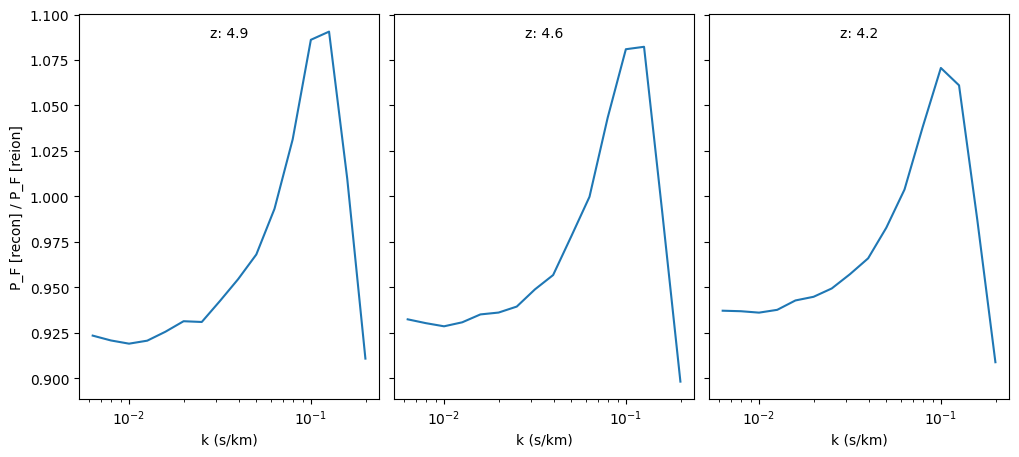

In [42]:
# Plot P_F ratio from (keir_recon) / (keir_reion_same_t) 

fig, axes = plt.subplots(1, len(scale_factors), figsize=(4* len(scale_factors), 5), sharex=True, sharey=True)
for ax, a, z in zip(axes, scale_factors, redshifts):

    recon_k, recon_power = flux_power_data['keir_recon'][a]
    reion_k, reion_power = flux_power_data['keir_reion_same_t'][a]

    interp_func = interp1d(recon_k, recon_power, kind='linear', bounds_error=False, fill_value="extrapolate")
    recon_power_rebinned = interp_func(kf)

    interp_func = interp1d(reion_k, reion_power, kind='linear', bounds_error=False, fill_value="extrapolate")
    reion_power_rebinned = interp_func(kf)

    ratio = recon_power_rebinned / reion_power_rebinned

    # ax.plot()
    ax.semilogx(kf, ratio)
    # ax.loglog(kf, sim_power_rebinned, label="Sim")
    ax.set_xlabel("k (s/km)")
    ax.text(0.5, 0.95, f"z: {z:.1f}", horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes)

# Only the leftmost panel keeps the y axis label and tick labels
axes[0].set_ylabel("P_F [recon] / P_F [reion]")
for ax in axes[1:]:
    ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(wspace=0.05)
plt.show()

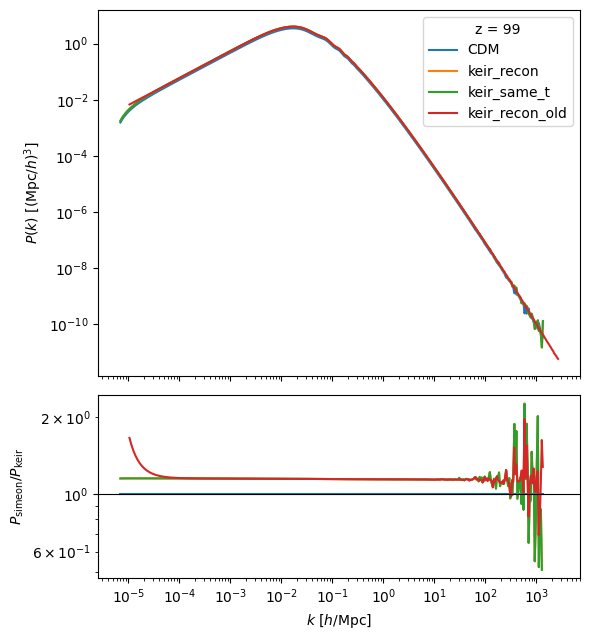

P_simeon/P_keir at k = 0.01, 1, 10, 30 h/Mpc: [1.151 1.145 1.142 1.142]


In [18]:
# Initial (z=99) total matter power spectrum, read directly from the input tables.
# keir: WDM_pk_99.dat (FileWithInputSpectrum in keir/paramfile.genic). simeon: theory/ics_matterpow_99.dat
# (identical for keir_recon and keir_reion_same_t). Shaded band: k_fund to k_Nyq of the simulation.
pk_files = {
    "CDM": "../class_pk_99.dat",
    # "keir (WDM)": "../WDM_pk_99.dat",
    "keir_recon": "keir_recon/theory/ics_matterpow_99.dat",
    "keir_same_t": "keir_reion_same_t/theory/ics_matterpow_99.dat",
    "keir_recon_old": "keir_recon/theory/ics_matterpow_99_old.dat",
}
pk_init = {name: np.loadtxt(fn, unpack=True) for name, fn in pk_files.items()}
fig, (top, bot) = plt.subplots(2, 1, figsize=(6, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

k_cdm, p_cdm = pk_init["CDM"]
for label in pk_files:
    k_sim, p_sim = pk_init[label]
    # evaluate keir on the simeon k grid (log-log interpolation) before dividing
    overlap = (k_sim >= k_cdm.min()) & (k_sim <= k_cdm.max())
    k_ratio = k_sim[overlap]
    pk_ratio = p_sim[overlap] / np.exp(np.interp(np.log(k_ratio), np.log(k_cdm), np.log(p_cdm)))

    top.loglog(k_sim, p_sim, label=label)
    bot.loglog(k_ratio, pk_ratio)
bot.axhline(1.0, color="k", lw=0.8)
top.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$")
bot.set_ylabel(r"$P_{\rm simeon}/P_{\rm keir}$")
bot.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$")
top.legend(title="z = 99")
plt.tight_layout()
plt.show()

dev = np.abs(pk_ratio - 1)
print(f"P_simeon/P_keir at k = 0.01, 1, 10, 30 h/Mpc:", np.interp(np.log([0.01, 1, 10, 30]), np.log(k_ratio), pk_ratio).round(3))